## Components of Feature Engineering

Feature engineering is a crucial step in the machine learning pipeline that involves creating new features or transforming existing ones to improve the performance of a model. The components of feature engineering include:

1. **Feature Creation**: This involves generating new features from the existing data. For example, if you have a dataset with a date column, you can create new features such as the day of the week, month, or year.
2. **Feature Transformation**: This involves modifying the scale or distribution of existing features. For example, you can apply logarithmic transformations to reduce skewness or normalize features to a standard scale.
3. **Feature Selection**: This involves choosing the most relevant features for the model. Techniques such as correlation analysis, recursive feature elimination, or feature importance from tree-based models can be used to select the best features.
4. **Feature Encoding**: This involves converting categorical variables into a format that can be used by machine learning algorithms. Techniques such as one-hot encoding, label encoding, or target encoding can be used for this purpose.

## Feature Scaling

Feature scaling is a technique used to standardize the range of independent variables or features of data.

### Standardization (Z-score normalization)
Standardization transforms the data to have a mean of 0 and a standard deviation of 1


In [21]:
import numpy as np
import pandas as pd

In [22]:
# Z-score normalization
np.random.seed(88)

n_students = 100

age = np.random.randint(20,60, n_students)

cgpa = np.random.normal(8, 3 , n_students)
cgpa = np.round(cgpa, 2)
cgpa = np.clip(cgpa, 4.0, 10.0)

placement_prob = (cgpa - 4.0) / 6.0  # Maps 4.0->0.0, 10.0->1.0
placement = (np.random.random(n_students) < placement_prob).astype(int)

df = pd.DataFrame({
    'age': age,
    'cgpa': cgpa,
    'placement': placement})

df['age_scaled'] = (df['age'] - df['age'].mean()) / df['age'].std()
df['cgpa_scaled'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

pd.reset_option('display.max_rows')
df

,age,cgpa,placement,age_scaled,cgpa_scaled
0,44,9.04,1,0.433300,0.752539
1,52,5.19,0,1.139288,-1.162002
2,35,4.00,0,-0.360936,-1.753770
3,40,8.94,1,0.080306,0.702811
4,57,4.15,0,1.580531,-1.679177
...,...,...,...,...,...
95,29,6.14,0,-0.890428,-0.689583
96,57,6.95,1,1.580531,-0.286783
97,20,4.00,0,-1.684664,-1.753770
98,56,7.41,0,1.492282,-0.058033


In [23]:
X_train = df[['age', 'cgpa']]

X_train_scaled = pd.DataFrame({'age_scaled': df['age_scaled'], 'cgpa_scaled': df['cgpa_scaled']})
np.round(X_train_scaled.describe(), 1)

,age_scaled,cgpa_scaled
count,100.0,100.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.7,-1.8
25%,-0.9,-0.8
50%,-0.0,0.1
75%,0.8,1.0
max,1.8,1.2


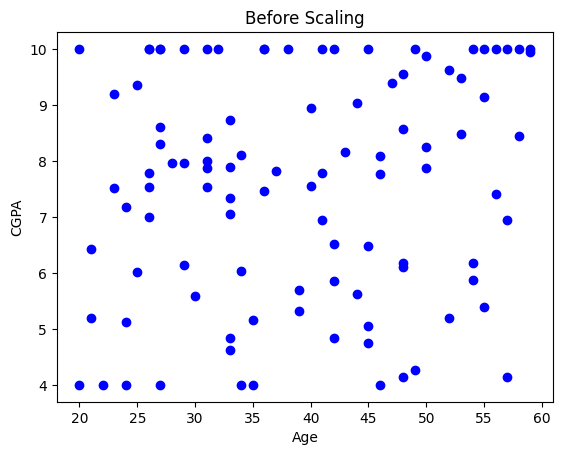

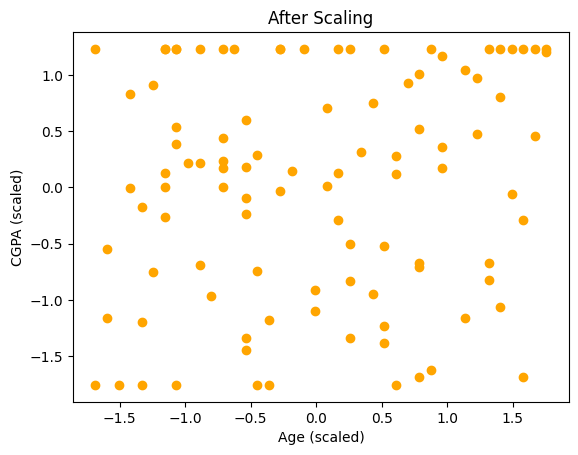

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.scatter(x=df['age'], y=df['cgpa'],color='blue')
plt.title('Before Scaling')
plt.xlabel('Age')
plt.ylabel('CGPA')
plt.show()

plt.scatter(x=df['age_scaled'], y=df['cgpa_scaled'] ,color='orange')
plt.title('After Scaling')
plt.xlabel('Age (scaled)')
plt.ylabel('CGPA (scaled)')
plt.show()

C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\4244487466.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['age'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\4244487466.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['cgpa'], color='orange', shade=True)


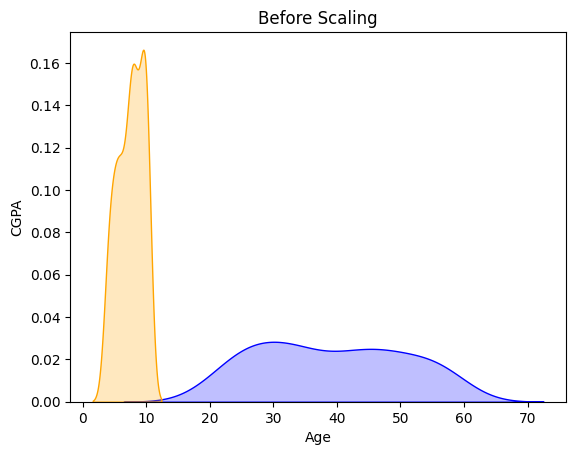

C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\4244487466.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['age_scaled'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\4244487466.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['cgpa_scaled'], color='orange', shade=True)


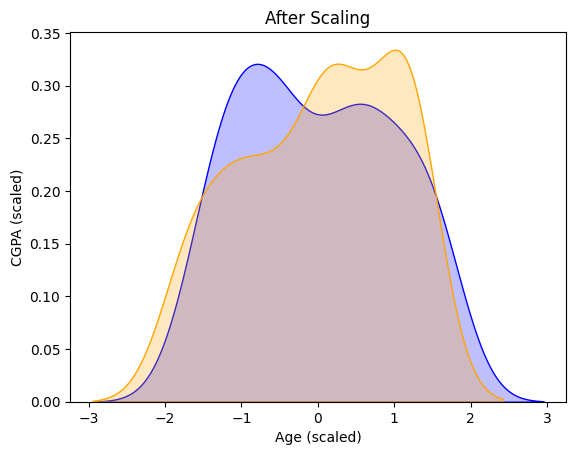

In [25]:
sns.kdeplot(x=X_train['age'], color='blue', shade=True)
sns.kdeplot(x=X_train['cgpa'], color='orange', shade=True)
plt.title('Before Scaling')
plt.xlabel('Age')
plt.ylabel('CGPA')
plt.show()

sns.kdeplot(x=X_train_scaled['age_scaled'], color='blue', shade=True)
sns.kdeplot(x=X_train_scaled['cgpa_scaled'], color='orange', shade=True)
plt.title('After Scaling')
plt.xlabel('Age (scaled)')
plt.ylabel('CGPA (scaled)')
plt.show()

### Algorithms that are sensitive to Standardization:

- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)
- Kmeans Clustering
- Principal Component Analysis (PCA)
- Logistic Regression
- Artificial Neural Networks (ANN)
- Gradient Descent based algorithms

### Normalization (Min-Max Scaling)
Normalization scales the data to a fixed range, usually 0 to 1.

#### Min-Max Scaling 

In [26]:
import sklearn.datasets as datasets
from sklearn.preprocessing import StandardScaler, MinMaxScaler

wine = datasets.load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [27]:
wine = wine_df[['alcohol', 'malic_acid', 'ash', 'magnesium','target']]
wine

,alcohol,malic_acid,ash,magnesium,target
0,14.23,1.71,2.43,127.0,0
1,13.20,1.78,2.14,100.0,0
2,13.16,2.36,2.67,101.0,0
3,14.37,1.95,2.50,113.0,0
4,13.24,2.59,2.87,118.0,0
...,...,...,...,...,...
173,13.71,5.65,2.45,95.0,2
174,13.40,3.91,2.48,102.0,2
175,13.27,4.28,2.26,120.0,2
176,13.17,2.59,2.37,120.0,2


In [28]:
from sklearn.model_selection import train_test_split

X = wine[['alcohol', 'malic_acid', 'ash', 'magnesium']]
y = wine['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=88)

In [29]:
# Min-Max Scaling
scalar = MinMaxScaler()

scalar.fit(X_train)

X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


In [30]:
np.round(X_train_scaled.describe(), decimals=1)

,alcohol,malic_acid,ash,magnesium
count,142.0,142.0,142.0,142.0
mean,0.5,0.3,0.5,0.3
std,0.2,0.2,0.2,0.2
min,0.0,0.0,0.0,0.0
25%,0.4,0.1,0.5,0.2
50%,0.5,0.2,0.5,0.3
75%,0.7,0.5,0.6,0.4
max,1.0,1.0,1.0,1.0


C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\793378467.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['alcohol'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\793378467.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train['malic_acid'], color='orange', shade=True)


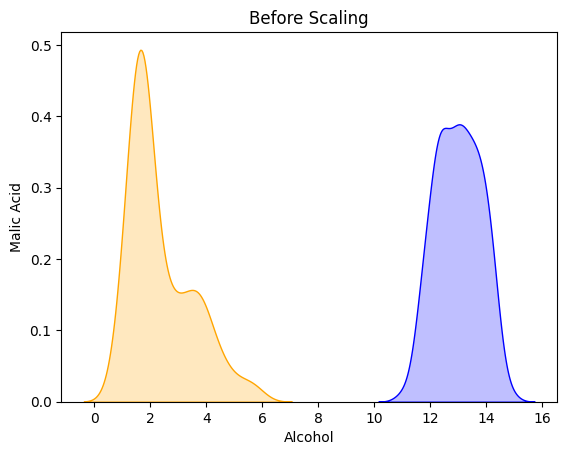

C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\793378467.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['alcohol'], color='blue', shade=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\793378467.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X_train_scaled['malic_acid'], color='orange', shade=True)


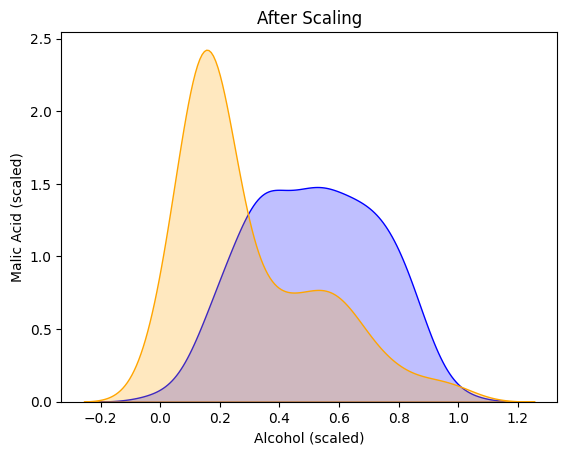

In [31]:
sns.kdeplot(x=X_train['alcohol'], color='blue', shade=True)
sns.kdeplot(x=X_train['malic_acid'], color='orange', shade=True)
plt.title('Before Scaling')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()

sns.kdeplot(x=X_train_scaled['alcohol'], color='blue', shade=True)
sns.kdeplot(x=X_train_scaled['malic_acid'], color='orange', shade=True)
plt.title('After Scaling')  
plt.xlabel('Alcohol (scaled)')
plt.ylabel('Malic Acid (scaled)')
plt.show()

#### Mean Normalization

**X_mean_norm = (X - X.mean()) / (X.max() - X.min())**

#### Max Abs Scaling
**X_max_abs_scaled = X / X.abs().max()**

#### Robust Scaling
Robust Scaling uses the median and the interquartile range for scaling, making it robust to outliers.

**X_robust_scaled = (X - X.median()) / (X.quantile(0.75) - X.quantile(0.25))**

It is Robust to outliers because it uses the median and interquartile range instead of mean and standard deviation, which can be heavily influenced by outliers.

### Encoding Categorical Data
Categorical data can be encoded using various techniques such as:

#### Ordinal Encoding

Ordinal encoding assigns a unique integer to each category in a feature. This method is suitable for ordinal data where the categories have a **meaningful order.** 
For example, if you have a feature "Education Level" with categories "High School", "Bachelor's", "Master's", and "PhD", you can encode them as 0, 1, 2, and 3 respectively.

In [32]:
import numpy as np
import pandas as pd

np.random.seed(88)

score = np.random.randint(0, 101, 100)

category = ['A' , 'B' , 'C']
categories = np.random.choice(category, 100)

df = pd.DataFrame({'score': score, 'category': categories})

grade = np.where(categories == 'A' , 2 , np.where(categories == 'B', 1, np.where(categories == 'C', 0, 0)))

df_with_ordinal = pd.DataFrame({'score': score, 'category': categories, 'grade': grade})
df_with_ordinal.head()

,score,category,grade
0,88,A,2
1,32,B,1
2,79,C,0
3,49,C,0
4,20,B,1


In [33]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['C', 'B', 'A']])
oe.fit(df[['category']])

df['category_encoded'] = oe.transform(df[['category']])
df.head()

,score,category,category_encoded
0,88,A,2.0
1,32,B,1.0
2,79,C,0.0
3,49,C,0.0
4,20,B,1.0


#### One-Hot Encoding
One-hot encoding creates binary columns for each category in a feature. This method is suitable for nominal data where the categories do not have a meaningful order. For example, if you have a feature "Color" with categories "Red", "Green", and "Blue", one-hot encoding would create three binary columns: "Color_Red", "Color_Green", and "Color_Blue".

In [34]:
#### One-Hot Encoding

target = np.random.randint(0,2,100)

color = ['Red', 'Green', 'Blue']
colors = np.random.choice(color, 100)

df_colors = pd.DataFrame({'color': colors, 'target': target})
df_colors.head()

,color,target
0,Green,0
1,Green,0
2,Red,1
3,Blue,0
4,Blue,0


In [35]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(categories=[['Blue', 'Green', 'Red']], drop='first')
encoded = ohe.fit_transform(df_colors[['color']]).toarray()
df_colors_encoded = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['color']))
df_colors_encoded.head()

,color_Green,color_Red
0,1.0,0.0
1,1.0,0.0
2,0.0,1.0
3,0.0,0.0
4,0.0,0.0


In [36]:
print(ohe.get_feature_names_out(['color']))

['color_Green' 'color_Red']


#### Column transformer
ColumnTransformer allows you to apply different transformations to different columns in your dataset. 

In [37]:
# Improved toy dataset: Cough and has_covid as categorical, Fever in Fahrenheit
import numpy as np
import pandas as pd

np.random.seed(42)
n = 100

ages = np.random.randint(18, 70, n)
genders = np.random.choice(['Male', 'Female'], n)
# Fever in Fahrenheit (simulate normal and feverish values)
fever = np.random.normal(loc=98.6, scale=2.5, size=n)
# Cough as categorical
cough = np.random.choice(['Yes', 'No'], n)
cities = np.random.choice(['Delhi', 'Mumbai', 'Bangalore', 'Chennai'], n)
# has_covid as categorical
has_covid = np.random.choice(['Yes', 'No'], n)

df_toy = pd.DataFrame({
    'Age': ages,
    'Gender': genders,
    'Fever_F': np.round(fever, 1),
    'Cough': cough,
    'City': cities,
    'has_covid': has_covid
})

# Introduce up to 10 random missing values
for _ in range(np.random.randint(5, 11)):
    row = np.random.randint(0, n)
    col = np.random.choice(df_toy.columns)
    df_toy.loc[row, col] = np.nan

df_toy.head(10)
df_toy.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        98 non-null     float64
 1   Gender     99 non-null     str    
 2   Fever_F    98 non-null     float64
 3   Cough      100 non-null    str    
 4   City       98 non-null     str    
 5   has_covid  99 non-null     str    
dtypes: float64(2), str(4)
memory usage: 4.8 KB


In [38]:
df_toy['Cough'].value_counts()

Cough
No     53
Yes    47
Name: count, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(df_toy.drop('has_covid', axis=1), df_toy['has_covid'], test_size=0.2, random_state=42)

In [40]:
X_train

,Age,Gender,Fever_F,Cough,City
55,37.0,Male,98.8,Yes,Delhi
88,38.0,Female,95.3,No,Mumbai
26,29.0,Male,101.7,No,Bangalore
42,68.0,Male,98.7,No,Mumbai
69,19.0,Female,99.8,Yes,Mumbai
...,...,...,...,...,...
60,25.0,Female,96.0,No,Chennai
71,59.0,Female,101.3,Yes,Chennai
14,57.0,Female,96.9,No,Bangalore
92,64.0,Female,100.9,Yes,Mumbai


In [41]:
### Doing without ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

## Handling missing values in Fever_F , Gender , Age , City , has_covid
si = SimpleImputer()
X_train_fever = si.fit_transform(X_train[['Fever_F']])
X_test_fever = si.transform(X_test[['Fever_F']])

X_train_age = si.fit_transform(X_train[['Age']])
X_test_age = si.transform(X_test[['Age']])

X_train_Gender = X_train['Gender'].fillna(X_train['Gender'].mode()[0], inplace=True)
X_test_Gender = X_test['Gender'].fillna(X_test['Gender'].mode()[0], inplace=True)

X_train_City = X_train['City'].fillna(X_train['City'].mode()[0], inplace=True)
X_test_City = X_test['City'].fillna(X_test['City'].mode()[0], inplace=True)

## Ordinal Encoding for Cough
oe = OrdinalEncoder(categories=[['No' , 'Yes']])
X_train_cough = oe.fit_transform(X_train[['Cough']])
X_test_cough = oe.transform(X_test[['Cough']])

## One-Hot Encoding for City and gender
ohe_city = OneHotEncoder(drop='first')
X_train_City = ohe_city.fit_transform(X_train_City.values.reshape(-1, 1)).toarray()
X_test_City = ohe_city.transform(X_test_City.values.reshape(-1, 1)).toarray()

ohe_gender = OneHotEncoder(drop='first')
X_train_Gender_ohe = ohe_gender.fit_transform(X_train_Gender.values.reshape(-1, 1)).toarray()
X_test_Gender_ohe = ohe_gender.transform(X_test_Gender.values.reshape(-1, 1)).toarray()

X_train_final = np.hstack((X_train_fever, X_train_age, X_train_cough, X_train_City, X_train_Gender_ohe))
X_test_final = np.hstack((X_test_fever, X_test_age, X_test_cough, X_test_City, X_test_Gender_ohe))

C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\3129026851.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X_train_Gender = X_train['Gender'].fillna(X_train['Gender'].mode()[0], inplace=True)
C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\3129026851.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFram

In [42]:
df_train = pd.DataFrame(X_train_final)
df_train.head()

,0,1,2,3,4,5,6
0,98.8,37.0,1.0,0.0,1.0,0.0,1.0
1,95.3,38.0,0.0,0.0,0.0,1.0,0.0
2,101.7,29.0,0.0,0.0,0.0,0.0,1.0
3,98.7,68.0,0.0,0.0,0.0,1.0,1.0
4,99.8,19.0,1.0,0.0,0.0,1.0,0.0


In [43]:
### Using ColumnTransformer
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer(
    transformers=[
        ('tnf1', SimpleImputer(), ['Fever_F', 'Age']),
        #('tnf2', SimpleImputer(), ['Gender' , 'Cough' , 'City']),
        ('tnf4', OrdinalEncoder(categories=[['No' , 'Yes']]), ['Cough']),
        ('tnf5', OneHotEncoder(drop='first'), ['City','Gender']),
    ],
    remainder='passthrough')

In [44]:
pd.DataFrame(transformer.fit_transform(X_train))

,0,1,2,3,4,5,6,7,8
0,98.8,37.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,95.3,38.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,101.7,29.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,98.7,68.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,99.8,19.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
75,96.0,25.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
76,101.3,59.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
77,96.9,57.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,100.9,64.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [45]:
X_train_final.shape

(80, 7)

In [46]:
# Get feature names for the transformed DataFrame
import numpy as np
from itertools import chain

# Fit the transformer
transformer.fit(X_train)

# Get feature names for each transformer
num_features = ['Fever_F', 'Age']
cough_feature = ['Cough']
city_gender_features = transformer.named_transformers_['tnf5'].get_feature_names_out(['City', 'Gender'])

# Combine all feature names
all_feature_names = list(num_features) + cough_feature + list(city_gender_features)

# Transform the data
X_train_transformed = transformer.transform(X_train)

# Create DataFrame with correct column names
df_transformed = pd.DataFrame(X_train_transformed, columns=all_feature_names)
df_transformed.head()

,Fever_F,Age,Cough,City_Chennai,City_Delhi,City_Mumbai,City_nan,Gender_Male,Gender_nan
0,98.8,37.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,95.3,38.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,101.7,29.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,98.7,68.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,99.8,19.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


# Mathemetical Transformations

## Log Transformation

#### Log transformation

Log transformation is a mathematical technique used to transform skewed data into a more normal distribution. It is particularly useful when dealing with data that has a long tail or is heavily skewed. The log transformation can help stabilize the variance and make the data more suitable for modeling.

#### How to Find if data is Normally Distributed?

1. **Histogram with KDE**: `sns.distplot(data['feature'], kde=True)`
2. **Q-Q Plot**: `sm.qqplot(data['feature'], line='s')`
3. pd.skew(data['feature']) and pd.kurtosis(data['feature'])


In [47]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler , FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer 

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [48]:
df = pd.read_csv('mlFolder/datasets/Titanic-Dataset.csv' , usecols=['Age', 'Fare', 'Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [50]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [51]:
df['Age'] = df['Age'].fillna(df['Age'].mean(), inplace=True)
df.isnull().sum()

C:\Users\biswa\AppData\Local\Temp\ipykernel_24792\3442923519.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(df['Age'].mean(), inplace=True)


Survived    0
Age         0
Fare        0
dtype: int64

In [52]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]
print(X.head() )
print(y.head() )  

    Age     Fare
0  22.0   7.2500
1  38.0  71.2833
2  26.0   7.9250
3  35.0  53.1000
4  35.0   8.0500
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


Text(0.5, 1.0, 'Q-Q Plot for Age_log')

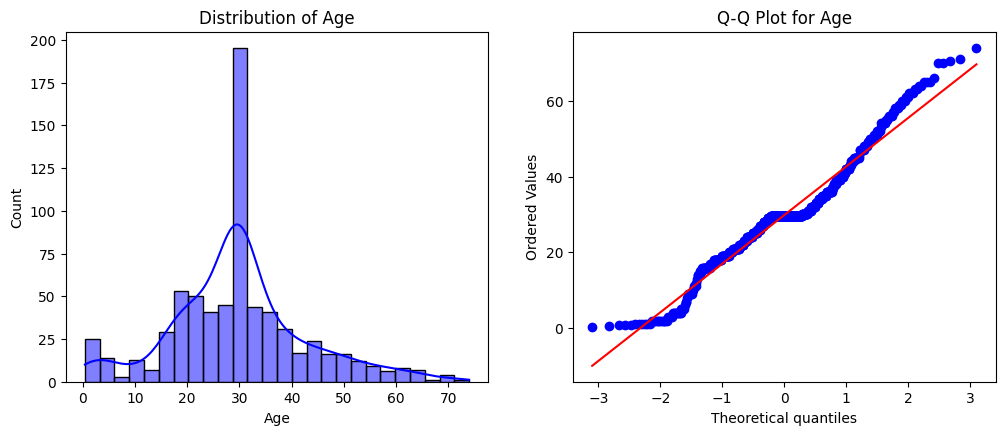

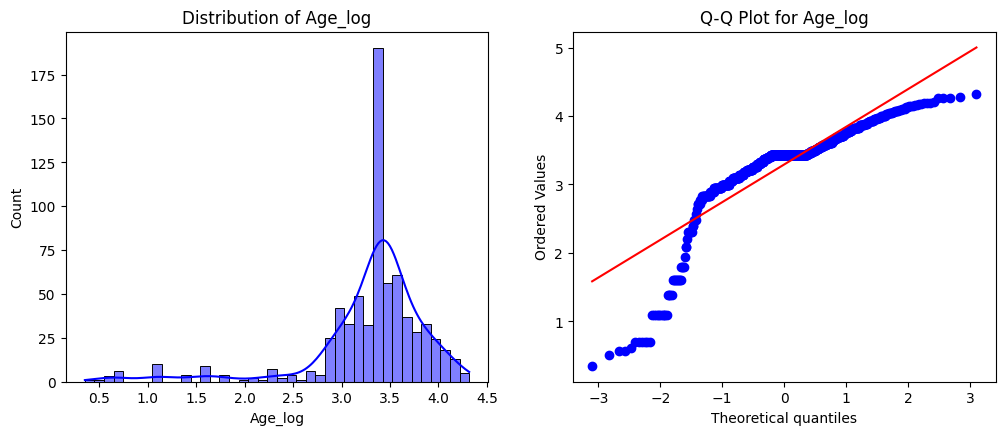

In [53]:
### Now will plot the QQ plot for Age and Fare to check the normality of the data. If the data is not normally distributed then we will apply log transformation to make it normally distributed.
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(88)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.histplot(X_train['Age'], kde=True, color='blue')
plt.title('Distribution of Age')

plt.subplot(2, 2, 2)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Age')

## Log transformation for Age
tnf1 = FunctionTransformer(func=np.log1p)
X_train['Age_log'] = tnf1.fit_transform(X_train[['Age']])

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 3)
sns.histplot(X_train['Age_log'], kde=True, color='blue')
plt.title('Distribution of Age_log')

plt.subplot(2, 2, 4)
stats.probplot(X_train['Age_log'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Age_log')

Text(0.5, 1.0, 'Q-Q Plot for Fare_log')

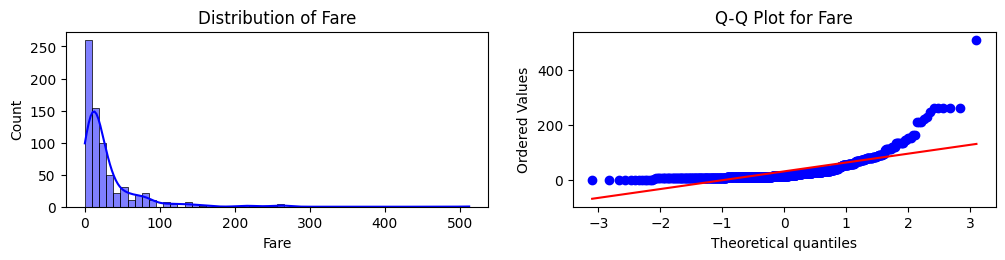

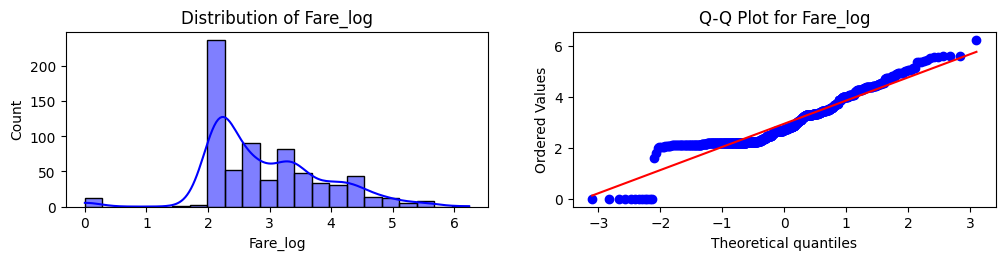

In [54]:
### Now will plot the QQ plot for Fare to check the normality of the data. If the data is not normally distributed then we will apply log transformation to make it normally distributed.
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(88)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)
sns.histplot(X_train['Fare'], kde=True, color='blue')
plt.title('Distribution of Fare')

plt.subplot(2, 2, 2)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Fare')

## Log transformation for Fare
tnf1 = FunctionTransformer(func=np.log1p)
X_train['Fare_log'] = tnf1.fit_transform(X_train[['Fare']])

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 3)
sns.histplot(X_train['Fare_log'], kde=True, color='blue')
plt.title('Distribution of Fare_log')

plt.subplot(2, 2, 4)
stats.probplot(X_train['Fare_log'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Fare_log')

In [55]:
from sklearn.model_selection import cross_val_score 

def apply_transformation(param_X):

    trf = ColumnTransformer(
        transformers=[
            ('tnf1' , FunctionTransformer(param_X) , ['Fare'])
        ], remainder='passthrough'
    )

    X_train_trf = trf.fit_transform(X_train)

    clf = LogisticRegression()

    print('Accuracy' , np.mean(cross_val_score(clf, X_train_trf, y_train, cv=10)))

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 2)
    stats.probplot(np.array(X_train_trf).flatten(), dist="norm", plot=plt)
    plt.title('Q-Q Plot for Fare after transformation')

    plt.subplot(1, 2, 1)
    stats.probplot(np.array(X_train['Fare']).flatten(), dist="norm", plot=plt)
    plt.title('Q-Q Plot for Fare before transformation')

    plt.show()

Accuracy 0.675586854460094


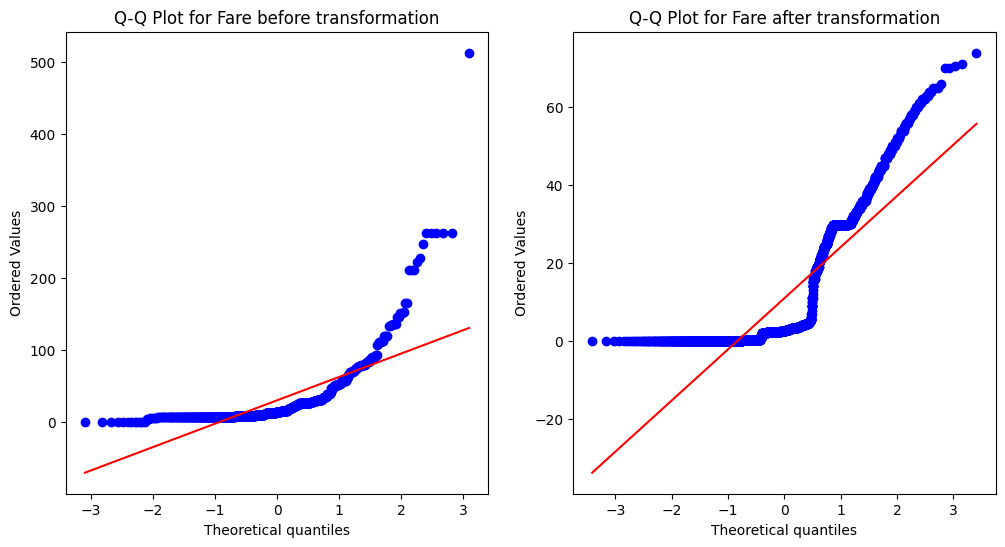

In [60]:
apply_transformation(lambda x: 1/(x + 1))

## Box-Cox Transformation

Box cox transformation is a family of power transformations that can be used to stabilize variance and make the data more normal. It is defined as:

$$\begin{array}{|c|c|} \hline
\lambda & \text{Transformation} \\ \hline
\lambda \neq 0 & y(\lambda) = \frac{y^{\lambda} - 1}{\lambda} \\ \hline
\lambda = 0 & y(\lambda) = \log(y) \\ \hline
\end{array}$$

The exponent here is a variable called lambda that varies over the range of -5 to 5. The optimal value of lambda can be found using maximum likelihood estimation.Finally we choose the optimal value (resulting in the best approximation to normality) for your variable and apply the transformation to your data.


$$
\begin{array}{|l|l|l|}
\hline
\textbf{Restriction} & \textbf{Description} & \textbf{Alternative} \\ \hline
\text{Data Sign} & \text{Must be strictly positive } (x > 0). & \text{Use Yeo-Johnson.} \\ \hline
\text{Outliers} & \text{Can distort the optimal } \lambda. & \text{Use RobustScaler or clip outliers.} \\ \hline
\text{Interpretability} & \text{Transformed units lack physical meaning.} & \text{Use Log transform (easier to explain).} \\ \hline
\text{Distribution} & \text{Only works for unimodal skewed data.} & \text{Use QuantileTransformer.} \\ \hline
\end{array}
$$

## Yeo-Johnson Transformation

This transformation is somewhat of an adjustment to the Box-Cox transformation that can handle both positive and negative values.